# Incremental Learning Framework for DNI Prediction

这个 notebook 是在你现有 **CLEAN Version: Prediction of DNI using Machine Learning** 的基础上，重新整理出的 **增量学习框架**。

核心思想：
1. 先用历史数据训练一个 **base model**
2. 按月切块新数据
3. 为每个 sky condition 维护一个 **replay buffer**
4. 每月从上一个 checkpoint 出发，做少量 epoch 的微调
5. 每个月评估三类模型和整体聚合表现

这个框架尽量保持和你原 notebook 一致：
- 继续使用 sky-condition based models
- 继续使用 `GHI / Temperature / Dew Point / Pressure / Kt / Solar Cos Zenith Angle / G0`
- 继续使用每个 sky condition 一个 scaler + 一个 neural network
- 继续保留物理约束 `0 <= DNI <= GHI / cos(theta_z)`

In [ ]:

# ===== 0. Basic Libraries =====
import os
import json
import math
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

## 1. Configuration

你只需要先改这里的路径和基础参数。

In [ ]:
# Load the original dataset from NSRDB (Year 2012 to 2023), which is uploaded to Google drive
path2023 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQvMAiptsZsmO8mLIZ2G1OocKFF7a4AfhOHALph05mcCeO1ZSD7W5DOy4FQ3jaLSIBQ42cEQqP0Init/pub?gid=569062119&single=true&output=csv"
file1 = pd.read_csv(path2023, skiprows=2)
path2022 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSAJ_YMVOLraVVnI2tksjsf9hrUA3uYHOfuMCrQP9CSXHfvXjGbi8-7Hh69DlWdDtLOlPDmeGL__8DZ/pub?gid=815357767&single=true&output=csv"
file2 = pd.read_csv(path2022, skiprows=2)
path2021 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmZne271RQ9xUgEdY8Obi7ziNnLItkh4I3j0Lf5VCgAEw5sNLISePnhygDdeTfhwDcuJV2aHeZlxYb/pub?gid=1640194307&single=true&output=csv"
file3 = pd.read_csv(path2021, skiprows=2)
path2020 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTOM6gmivrhzapDo6rYZ4JHczS3TyrviHlxXLz3ykKX_TxgXfYC1XPkp5H5xV45EHHS7sKC1nLK3FiI/pub?gid=215456109&single=true&output=csv"
file4 = pd.read_csv(path2020, skiprows=2)
path2019 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQPeuZVc0alY-YJccyi8WxcgxmCEw24YE5_CKBStkiNc8PRNau6aTTHcdXfxQtntPf5kAeZXK-2uSoo/pub?gid=1714947388&single=true&output=csv"
file5 = pd.read_csv(path2019, skiprows=2)
path2018 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQVh7iGsp_CatnDRfpuDx6oCayjuSc9DdXtfC8OKfTmB_1cWL2PwYaf36LPG0vS9POHFLXexcQjDjoB/pub?gid=1512810097&single=true&output=csv"
file6 = pd.read_csv(path2018, skiprows=2)
path2017 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vS_Ytvf4h0uKy2QW8nNo-8RELfKjRseYDPg72ptlJs2BIwfVKVsEzzlNf0DDw2n_n-BMozfgRpnzyHw/pub?gid=113656081&single=true&output=csv"
file7 = pd.read_csv(path2017, skiprows=2)
path2016 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRfV_nFl3E_HggoR04W9p2fHuNK3wHUAZFQ_gjgHBDCT5HyjWCzNpLbl3sbAp4gT_91Mq0ybh-vD9G8/pub?output=csv"
file8 = pd.read_csv(path2016, skiprows=2)
path2015 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQ8XuIEjq8gm928owHsDtrIsVtWlnK_pzvkttEOtLilR8evkYnMjzvoLnfjr76GGufC6Hskvy2nspKB/pub?gid=985444057&single=true&output=csv"
file9 = pd.read_csv(path2015, skiprows=2)
path2014 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSiforBrv6YMsLMYGOEogK4rdVKz2sVBIGrUad2CMUDAwI5x3dD79KpfXOvpDAvni9uqPRya2IgesPz/pub?gid=1061926971&single=true&output=csv"
file10 = pd.read_csv(path2014, skiprows=2)
path2013 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTg4Gn7eN3p9f34gGqEw4Bn0OnPCfl5PAjSdOcxpjPM-T9NxT2Nrcn3lSixmuRshaDIoSisUW9osNjf/pub?gid=1373472215&single=true&output=csv"
file11 = pd.read_csv(path2013, skiprows=2)
path2012 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRPDtmsWHFIiqVYsjSD7Bu80DvP4DQZlt-1nT5CHyVzgXjMVHvy_1HjH00TglfyYhIB9yr9LfCSIqt_/pub?gid=1879251878&single=true&output=csv"
file12 = pd.read_csv(path2012, skiprows=2)

path2011 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRcbUjAhgPPekxOq4VpDEjGNXI5Gi21vjwCTA69KlfMRpDclblDLqJcRMNL4JAksb7kCESxHDpE4ghF/pub?gid=579415269&single=true&output=csv"
file13 = pd.read_csv(path2011, skiprows=2)


In [ ]:
# Combinee all files into a single DataFrame
files = [file13, file12, file11, file10, file9, file8, file7, file6, file5, file4, file3, file2, file1]
all_files = pd.concat(files, ignore_index=True)

# Display the first few rows of selected file
df = all_files.copy()
print(f"File shape: {df.shape}")
df.head()

File shape: (227760, 46)


,Year,Month,Day,Hour,Minute,DNI,DHI,GHI,Dew Point,Temperature,...,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45
0,2011,1,1,0,0,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,1,1,0,30,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,1,1,1,0,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,1,1,1,30,0,0,0,-0.1,-0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,1,1,2,0,0,0,0,-0.2,-0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# ===== 1. Configuration =====
# DATA_PATH = "YOUR_DATA.csv"              # 改成你的总数据文件
OUTPUT_DIR = Path("incremental_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# 时间列和基础列（根据你的原始数据格式）
TIME_COLS = ["Year", "Month", "Day", "Hour", "Minute"]
RAW_FEATURE_COLS = ["GHI", "Temperature", "Dew Point", "Pressure"]

TARGET_COL = "DNI"

# 最终模型使用的特征（保持和你原 notebook 一致）
MODEL_FEATURE_COLS = [
    "GHI",
    "Temperature",
    "Dew Point",
    "Pressure",
    "Kt",
    "Solar Cos Zenith Angle",
    "G0"
]

# Sky condition thresholds（沿用你的现有逻辑）
OVERCAST_MAX = 0.35
PARTLY_CLOUDY_MAX = 0.70

# 增量学习相关参数
BASE_TRAIN_END = "2021-12-31 23:59:59"   # 历史 base model 截止时间，可按需修改
INCREMENTAL_START = "2022-01-01 00:00:00"
TEST_START = "2023-01-01 00:00:00"

REPLAY_CAPACITY_PER_CONDITION = 12000
REPLAY_SAMPLE_SIZE_PER_UPDATE = 3000
INCREMENTAL_EPOCHS = 15
BASE_EPOCHS = 100
BATCH_SIZE = 32

LATITUDE = 40.65
LONGITUDE = -75.38
ELEVATION = 106
TZ_OFFSET = -5
SOLAR_CONSTANT = 1366.1

## 2. Utility Functions

这里把你原 notebook 里的核心计算整理成统一函数：
- total minutes
- day of year
- extraterrestrial radiation
- zenith / cos(zenith)
- Kt
- sky condition label

In [ ]:

# ===== 2. Utility Functions =====
from datetime import datetime, timedelta, timezone

def calculate_total_minutes(years, months, days, hours, minutes):
    dates = pd.to_datetime(
        {
            "year": years,
            "month": months,
            "day": days,
            "hour": hours,
            "minute": minutes
        }
    )
    start = dates.min()
    return ((dates - start).dt.total_seconds() // 60).astype(int).values

def datetime_to_day_of_year(years, months, days, hours=None, minutes=None):
    if hours is None:
        hours = np.zeros(len(years), dtype=int)
    if minutes is None:
        minutes = np.zeros(len(years), dtype=int)

    dates = pd.to_datetime(
        {
            "year": years,
            "month": months,
            "day": days,
            "hour": hours,
            "minute": minutes
        }
    )
    return dates.dt.dayofyear.values

def dew_point_calculator(temp_c, rel_humidity):
    a = 17.27
    b = 237.7
    T = np.asarray(temp_c, dtype=float)
    RH = np.asarray(rel_humidity, dtype=float) / 100.0
    RH = np.clip(RH, 1e-6, 1.0)
    gamma = (a * T) / (b + T) + np.log(RH)
    dew = (b * gamma) / (a - gamma)
    return dew

def extraterrestrial_irradiance(day_of_year, solar_constant=SOLAR_CONSTANT):
    # 和你现有 presentation / notebook 里的公式保持一致
    return solar_constant * (1 + 0.033 * np.cos(np.deg2rad(360 * day_of_year / 365.0)))

def solar_zenith_approx(df, latitude=LATITUDE, longitude=LONGITUDE, tz_offset=TZ_OFFSET):
    # 一个不依赖 astral / pvlib 的简化版本，便于框架迁移
    # 如果你想完全和旧 notebook 一样，可替换成原先的 astral 计算函数
    lat_rad = np.deg2rad(latitude)
    doy = datetime_to_day_of_year(df["Year"], df["Month"], df["Day"], df["Hour"], df["Minute"])

    hour_decimal = df["Hour"].values + df["Minute"].values / 60.0
    decl = np.deg2rad(23.45 * np.sin(np.deg2rad(360 * (284 + doy) / 365.0)))
    hour_angle = np.deg2rad(15 * (hour_decimal - 12))

    cos_zenith = (
        np.sin(lat_rad) * np.sin(decl) +
        np.cos(lat_rad) * np.cos(decl) * np.cos(hour_angle)
    )
    cos_zenith = np.clip(cos_zenith, -1, 1)
    zenith_deg = np.rad2deg(np.arccos(cos_zenith))
    return zenith_deg, np.clip(cos_zenith, 0, None)

def assign_sky_condition(kt):
    if kt <= OVERCAST_MAX:
        return "overcast"
    elif kt <= PARTLY_CLOUDY_MAX:
        return "partly_cloudy"
    return "clear_sky"

def constrain_dni_predictions(y_pred, ghi, cos_theta_z):
    upper_limit = np.where(cos_theta_z > 0, ghi / np.maximum(cos_theta_z, 1e-6), np.inf)
    return np.clip(y_pred, 0, upper_limit)

## 3. Feature Engineering

这里是整个增量框架最重要的一步：  
不管是 base training 还是 monthly update，都必须走 **完全一致** 的预处理流程。

In [ ]:

# ===== 3. Feature Engineering =====
def prepare_features(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

    # 时间戳
    df["timestamp"] = pd.to_datetime(df[TIME_COLS])
    df = df.sort_values("timestamp").reset_index(drop=True)

    # 如果没有 Dew Point，但有 Relative Humidity，则自动补
    if "Dew Point" not in df.columns and "Relative Humidity" in df.columns:
        df["Dew Point"] = dew_point_calculator(df["Temperature"], df["Relative Humidity"])

    # 基础时间特征
    df["Total Minutes"] = calculate_total_minutes(
        df["Year"], df["Month"], df["Day"], df["Hour"], df["Minute"]
    )
    df["DayOfYear"] = datetime_to_day_of_year(
        df["Year"], df["Month"], df["Day"], df["Hour"], df["Minute"]
    )

    # Zenith / cos(zenith)
    theta_z, cos_zenith = solar_zenith_approx(df)
    df["Zenith Angle"] = theta_z
    df["Solar Cos Zenith Angle"] = cos_zenith

    # Extraterrestrial radiation
    df["DNIextra"] = extraterrestrial_irradiance(df["DayOfYear"].values)
    df["G0"] = df["DNIextra"] * df["Solar Cos Zenith Angle"]

    # Remove night-time effect in feature engineering, but keep original rows first
    df.loc[df["Zenith Angle"] > 90, "G0"] = 0

    # Kt
    df["Kt"] = 0.0
    valid = df["G0"] > 0
    df.loc[valid, "Kt"] = df.loc[valid, "GHI"] / df.loc[valid, "G0"]
    df["Kt"] = df["Kt"].replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)

    # Daytime flag
    df["is_daytime"] = df["Zenith Angle"] < 90

    # Sky condition
    df["sky_condition"] = df["Kt"].apply(assign_sky_condition)

    return df

def daytime_only(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["is_daytime"]].copy().reset_index(drop=True)

## 4. Model Definition

这里直接沿用你原 notebook 的神经网络主干：
- Dense(128) + BN + ReLU
- Dense(64) + BN + ReLU
- Dense(32) + BN + ReLU
- Dense(1)

In [ ]:

# ===== 4. Model Definition =====
def build_dni_model(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mean_absolute_error", "mean_squared_error"]
    )
    return model

def fit_model(model, X_train, y_train, X_val, y_val, model_path, epochs=BASE_EPOCHS):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(model_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    return history

## 5. Replay Buffer

根据 pdf 的流程，每个 sky condition 都要维护一个 replay buffer。  
这里我给你一个更适合你项目的版本：

- 每个 condition 一个 buffer
- buffer 里保存 **最近样本 + 代表性样本**
- 用 bucket 方式做分层抽样，避免只记住某一种 irradiance 水平
- 超容量时优先淘汰最老数据

In [ ]:

# ===== 5. Replay Buffer =====
class ReplayBuffer:
    def __init__(self, capacity=REPLAY_CAPACITY_PER_CONDITION, random_state=42):
        self.capacity = capacity
        self.random_state = random_state
        self.data = pd.DataFrame()

    def __len__(self):
        return len(self.data)

    def update(self, new_df: pd.DataFrame, bucket_col="DNI", n_buckets=5):
        if new_df.empty:
            return

        df = new_df.copy().sort_values("timestamp")

        # 为了保留代表性，按 bucket 分层采样后并入 buffer
        if len(df) > self.capacity:
            df = self._bucket_sample(df, bucket_col=bucket_col, total_n=self.capacity, n_buckets=n_buckets)

        combined = pd.concat([self.data, df], ignore_index=True).sort_values("timestamp")

        # 若超过容量，先整体按时间保留最近数据，
        # 再做一次 bucket sample，尽量兼顾“新鲜度 + 多样性”
        if len(combined) > self.capacity:
            recent_pool = combined.tail(min(len(combined), self.capacity * 3))
            combined = self._bucket_sample(
                recent_pool,
                bucket_col=bucket_col,
                total_n=self.capacity,
                n_buckets=n_buckets
            ).sort_values("timestamp")

        self.data = combined.reset_index(drop=True)

    def sample(self, n=REPLAY_SAMPLE_SIZE_PER_UPDATE, bucket_col="DNI", n_buckets=5):
        if self.data.empty:
            return self.data.copy()

        n = min(n, len(self.data))
        return self._bucket_sample(
            self.data,
            bucket_col=bucket_col,
            total_n=n,
            n_buckets=n_buckets
        ).reset_index(drop=True)

    def _bucket_sample(self, df, bucket_col="DNI", total_n=1000, n_buckets=5):
        if len(df) <= total_n:
            return df.copy()

        work = df.copy()

        if work[bucket_col].nunique() < n_buckets:
            return work.sample(total_n, random_state=self.random_state)

        work["_bucket"] = pd.qcut(
            work[bucket_col],
            q=n_buckets,
            duplicates="drop"
        )

        groups = []
        per_bucket = max(1, total_n // work["_bucket"].nunique())

        for _, g in work.groupby("_bucket", observed=False):
            take = min(len(g), per_bucket)
            groups.append(g.sample(take, random_state=self.random_state))

        sampled = pd.concat(groups, ignore_index=True)

        if len(sampled) < total_n:
            leftover = work.drop(sampled.index, errors="ignore")
            if not leftover.empty:
                extra_n = min(total_n - len(sampled), len(leftover))
                sampled = pd.concat(
                    [sampled, leftover.sample(extra_n, random_state=self.random_state)],
                    ignore_index=True
                )

        return sampled.drop(columns=["_bucket"], errors="ignore")

## 6. Condition-Specific Data Helper

In [ ]:

# ===== 6. Condition-Specific Data Helper =====
CONDITIONS = ["overcast", "partly_cloudy", "clear_sky"]

def split_by_condition(df: pd.DataFrame):
    result = {}
    for cond in CONDITIONS:
        result[cond] = df[df["sky_condition"] == cond].copy().reset_index(drop=True)
    return result

def make_xy(df: pd.DataFrame):
    X = df[MODEL_FEATURE_COLS].copy()
    y = df[TARGET_COL].copy()
    return X, y

def evaluate_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
    }

## 7. Base Training

这一步对应 pdf 里的：

- Step 1: Preprocess historical dataset
- Step 2: Split into sky-condition subsets
- Step 3: Train base models
- Step 5: Initialize replay buffers

In [ ]:

# ===== 7. Base Training =====
def train_base_models(df_daytime: pd.DataFrame):
    base_df = df_daytime[df_daytime["timestamp"] <= pd.Timestamp(BASE_TRAIN_END)].copy()
    by_cond = split_by_condition(base_df)

    artifacts = {}
    replay_buffers = {}

    for cond, cond_df in by_cond.items():
        print(f"\n===== Base training: {cond} =====")
        if cond_df.empty:
            print(f"[Skip] No data for {cond}")
            continue

        X, y = make_xy(cond_df)
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=SEED
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = build_dni_model(input_dim=X_train.shape[1])
        model_path = OUTPUT_DIR / f"base_model_{cond}.keras"
        history = fit_model(
            model,
            X_train_scaled, y_train,
            X_val_scaled, y_val,
            model_path=model_path,
            epochs=BASE_EPOCHS
        )

        best_model = keras.models.load_model(model_path)

        # 初始化 replay buffer：从 base data 中保留代表性样本
        buffer = ReplayBuffer(capacity=REPLAY_CAPACITY_PER_CONDITION, random_state=SEED)
        buffer.update(cond_df, bucket_col="DNI", n_buckets=5)

        artifacts[cond] = {
            "scaler": scaler,
            "model": best_model,
            "history": history,
            "last_checkpoint": model_path
        }
        replay_buffers[cond] = buffer

    return artifacts, replay_buffers

## 8. Monthly Block Generator

对应 pdf 的：
- Step 4: Partition data into monthly blocks `B1, B2, ..., BT`

In [ ]:

# ===== 8. Monthly Block Generator =====
def monthly_blocks(df_daytime: pd.DataFrame):
    inc_df = df_daytime[df_daytime["timestamp"] >= pd.Timestamp(INCREMENTAL_START)].copy()
    if inc_df.empty:
        return []

    inc_df["year_month"] = inc_df["timestamp"].dt.to_period("M")
    blocks = []
    for ym, g in inc_df.groupby("year_month"):
        blocks.append((str(ym), g.sort_values("timestamp").reset_index(drop=True)))
    return blocks

## 9. Incremental Update Loop

这一步就是整个新框架的核心，对应 pdf 的：
- Load monthly block
- preprocess
- extract condition subset
- sample replay data
- concatenate old + new
- load checkpoint
- incremental training
- save updated checkpoint
- update replay buffer
- evaluate monthly performance

In [ ]:

# ===== 9. Incremental Update Loop =====
def incremental_update_for_condition(
    cond: str,
    monthly_df: pd.DataFrame,
    artifacts: dict,
    replay_buffers: dict,
    epochs=INCREMENTAL_EPOCHS
):
    cond_month = monthly_df[monthly_df["sky_condition"] == cond].copy().reset_index(drop=True)
    if cond_month.empty or cond not in artifacts:
        return None

    scaler = artifacts[cond]["scaler"]
    prev_ckpt = artifacts[cond]["last_checkpoint"]
    replay_df = replay_buffers[cond].sample(
        n=REPLAY_SAMPLE_SIZE_PER_UPDATE,
        bucket_col="DNI",
        n_buckets=5
    )

    # 新数据 + replay 数据
    train_df = pd.concat([cond_month, replay_df], ignore_index=True).drop_duplicates()
    X_train_full, y_train_full = make_xy(train_df)
    X_month_only, y_month_only = make_xy(cond_month)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=SEED
    )

    # 是否重新 fit scaler？
    # 这里为了和原有 base pipeline 保持一致，采用“在训练集上重新 fit 当前 scaler”的方式
    # 如果你想更稳，可以改成 partial strategy 或固定 base scaler。
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_month_scaled = scaler.transform(X_month_only)

    model = keras.models.load_model(prev_ckpt)

    new_ckpt = OUTPUT_DIR / f"incremental_{cond}_{monthly_df['timestamp'].dt.strftime('%Y%m').iloc[0]}.keras"
    history = fit_model(
        model,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        model_path=new_ckpt,
        epochs=epochs
    )
    updated_model = keras.models.load_model(new_ckpt)

    # 月度评估（只评估该月新数据）
    month_pred = updated_model.predict(X_month_scaled, verbose=0).flatten()
    month_pred = constrain_dni_predictions(
        month_pred,
        X_month_only["GHI"].values,
        X_month_only["Solar Cos Zenith Angle"].values
    )
    metrics = evaluate_regression(y_month_only, month_pred)

    # 更新 artifacts
    artifacts[cond]["scaler"] = scaler
    artifacts[cond]["model"] = updated_model
    artifacts[cond]["history"] = history
    artifacts[cond]["last_checkpoint"] = new_ckpt

    # 更新 replay buffer
    replay_buffers[cond].update(cond_month, bucket_col="DNI", n_buckets=5)

    return {
        "condition": cond,
        "n_month_samples": len(cond_month),
        **metrics
    }

def run_incremental_learning(df_daytime, artifacts, replay_buffers):
    blocks = monthly_blocks(df_daytime)
    monthly_reports = []

    for ym, block_df in blocks:
        print(f"\n==============================")
        print(f"Processing monthly block: {ym}")
        print(f"==============================")

        report_rows = []
        for cond in CONDITIONS:
            result = incremental_update_for_condition(
                cond=cond,
                monthly_df=block_df,
                artifacts=artifacts,
                replay_buffers=replay_buffers,
                epochs=INCREMENTAL_EPOCHS
            )
            if result is not None:
                result["month"] = ym
                report_rows.append(result)

        if report_rows:
            monthly_reports.extend(report_rows)

    report_df = pd.DataFrame(monthly_reports)
    return report_df, artifacts, replay_buffers

## 10. Aggregated Prediction Across Three Conditions

对应 pdf 的：
- Step 15: Aggregate predictions from all three conditions
- Step 16: Compute overall metrics

In [ ]:

# ===== 10. Aggregated Prediction Across Three Conditions =====
def predict_all_conditions(df_input: pd.DataFrame, artifacts: dict):
    df = df_input.copy().reset_index(drop=True)
    preds = np.zeros(len(df))

    for cond in CONDITIONS:
        mask = df["sky_condition"] == cond
        if mask.sum() == 0 or cond not in artifacts:
            continue

        X_cond = df.loc[mask, MODEL_FEATURE_COLS]
        scaler = artifacts[cond]["scaler"]
        model = artifacts[cond]["model"]

        X_scaled = scaler.transform(X_cond)
        pred = model.predict(X_scaled, verbose=0).flatten()
        pred = constrain_dni_predictions(
            pred,
            X_cond["GHI"].values,
            X_cond["Solar Cos Zenith Angle"].values
        )
        preds[mask] = pred

    return preds

def evaluate_overall(df_eval: pd.DataFrame, artifacts: dict, title="Overall Evaluation"):
    y_true = df_eval[TARGET_COL].values
    y_pred = predict_all_conditions(df_eval, artifacts)
    metrics = evaluate_regression(y_true, y_pred)

    print(f"\n{title}")
    print("-" * len(title))
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return y_pred, metrics

## 11. Full Pipeline Runner

In [ ]:

# ===== 11. Full Pipeline Runner =====
# Step A: load and preprocess
df_raw = DATA_PATH.copy()
df_all = prepare_features(df_raw)
df_day = daytime_only(df_all)

print("Raw shape:", df_raw.shape)
print("Prepared shape:", df_all.shape)
print("Daytime shape:", df_day.shape)

# Step B: base training
artifacts, replay_buffers = train_base_models(df_day)

# Step C: incremental training by month
monthly_report_df, artifacts, replay_buffers = run_incremental_learning(
    df_day, artifacts, replay_buffers
)

if not monthly_report_df.empty:
    display(monthly_report_df.head())
    monthly_report_df.to_csv(OUTPUT_DIR / "monthly_incremental_report.csv", index=False)

# Step D: overall test evaluation
test_df = df_day[df_day["timestamp"] >= pd.Timestamp(TEST_START)].copy()
if not test_df.empty:
    y_pred_test, test_metrics = evaluate_overall(
        test_df,
        artifacts,
        title="Final Aggregated Test Performance"
    )
    test_df["Predicted DNI"] = y_pred_test
    test_df.to_csv(OUTPUT_DIR / "final_test_predictions.csv", index=False)

Raw shape: (227760, 46)
Prepared shape: (227760, 56)
Daytime shape: (113855, 56)

===== Base training: overcast =====
Epoch 1/100
798/813 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1081.6479 - mean_absolute_error: 10.5460 - mean_squared_error: 1081.6479
Epoch 1: val_loss improved from None to 908.86963, saving model to incremental_outputs/base_model_overcast.keras

Epoch 1: finished saving model to incremental_outputs/base_model_overcast.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1038.0854 - mean_absolute_error: 10.9272 - mean_squared_error: 1038.0854 - val_loss: 908.8696 - val_mean_absolute_error: 11.3082 - val_mean_squared_error: 908.8696
Epoch 2/100
808/813 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 902.2413 - mean_absolute_error: 11.3634 - mean_squared_error: 902.2413
Epoch 2: val_loss improved from 908.86963 to 893.24152, saving model to incremental_outputs/base_model_overcast.keras

Epoch 2: finished saving model to incremental_outputs/base_model_overcast.keras
813/813 ━━


Processing monthly block: 2022-02
Epoch 1/15
69/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1300.1077 - mean_absolute_error: 18.8966 - mean_squared_error: 1300.1077
Epoch 1: val_loss improved from None to 1442.37573, saving model to incremental_outputs/incremental_overcast_202202.keras

Epoch 1: finished saving model to incremental_outputs/incremental_overcast_202202.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1344.3121 - mean_absolute_error: 18.8937 - mean_squared_error: 1344.3121 - val_loss: 1442.3757 - val_mean_absolute_error: 17.9354 - val_mean_squared_error: 1442.3757
Epoch 2/15
73/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1233.1252 - mean_absolute_error: 18.5548 - mean_squared_error: 1233.1252
Epoch 2: val_loss did not improve from 1442.37573
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1256.9800 - mean_absolute_error: 18.5212 - mean_squared_error: 1256.9800 - val_loss: 1442.9218 - val_mean_absolute_error: 18.1909 - val_mean_squared_error: 1442.9218
Epoch 3/15
69/78

Epoch 1/15
69/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12612.2369 - mean_absolute_error: 81.1149 - mean_squared_error: 12612.2369
Epoch 1: val_loss improved from None to 10283.78125, saving model to incremental_outputs/incremental_partly_cloudy_202202.keras

Epoch 1: finished saving model to incremental_outputs/incremental_partly_cloudy_202202.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 12377.2607 - mean_absolute_error: 81.9690 - mean_squared_error: 12377.2607 - val_loss: 10283.7812 - val_mean_absolute_error: 74.0354 - val_mean_squared_error: 10283.7812
Epoch 2/15
70/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12317.1011 - mean_absolute_error: 81.1566 - mean_squared_error: 12317.1011
Epoch 2: val_loss did not improve from 10283.78125
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 11923.4004 - mean_absolute_error: 80.8960 - mean_squared_error: 11923.4004 - val_loss: 10317.5537 - val_mean_absolute_error: 74.3603 - val_mean_squared_error: 10317.5537
Epoch 3/15
76/79 ━━━━━━━━━

,condition,n_month_samples,R2,MAE,MSE,month
0,overcast,162,0.623475,15.553147,906.611156,2022-01
1,partly_cloudy,236,0.757049,85.983933,14909.126903,2022-01
2,clear_sky,191,0.832200,46.708060,5853.030377,2022-01
3,overcast,209,0.609768,17.199249,1597.952752,2022-02
4,partly_cloudy,151,0.739274,109.977638,18869.357353,2022-02



Final Aggregated Test Performance
---------------------------------
R2: 0.9652
MAE: 40.1640
MSE: 3979.0994


## 12. Optional Visualization

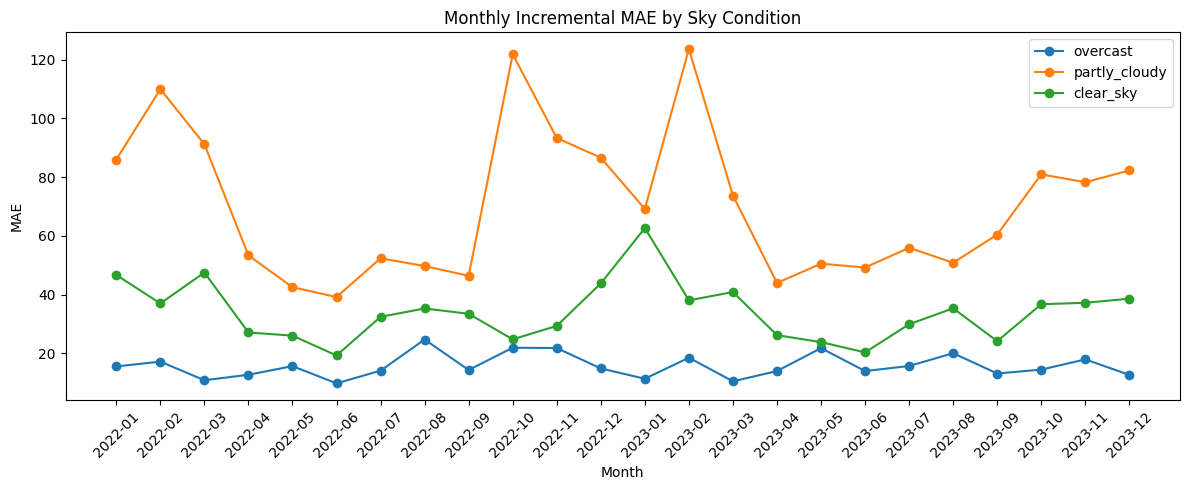

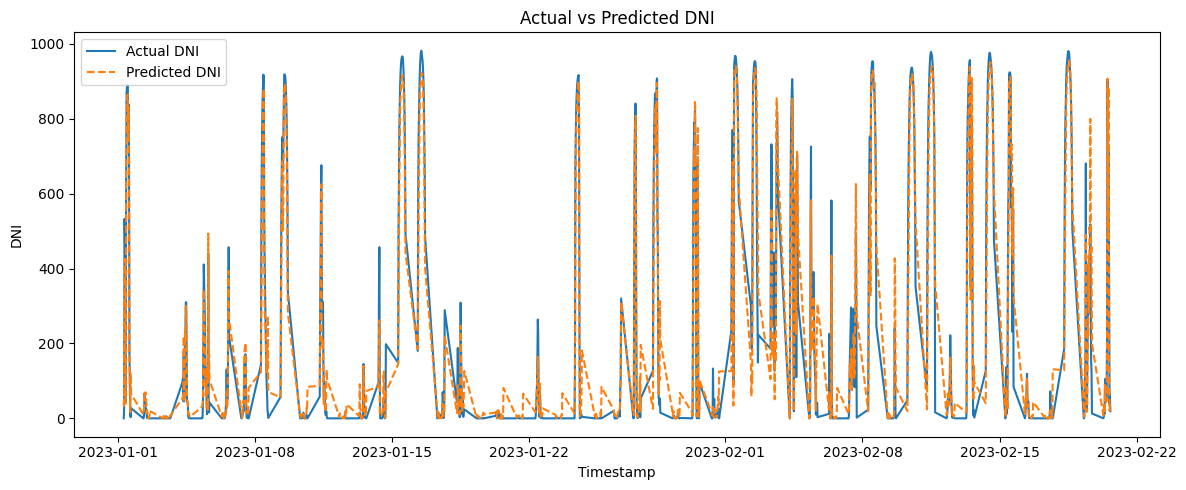

In [ ]:

# ===== 12. Optional Visualization =====
if 'monthly_report_df' in globals() and not monthly_report_df.empty:
    plt.figure(figsize=(12, 5))
    for cond in CONDITIONS:
        temp = monthly_report_df[monthly_report_df["condition"] == cond]
        if not temp.empty:
            plt.plot(temp["month"], temp["MAE"], marker="o", label=cond)

    plt.xticks(rotation=45)
    plt.title("Monthly Incremental MAE by Sky Condition")
    plt.xlabel("Month")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'test_df' in globals() and not test_df.empty and "Predicted DNI" in test_df.columns:
    plot_df = test_df.copy()
    plot_df = plot_df.sort_values("timestamp").head(1000)

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["timestamp"], plot_df["DNI"], label="Actual DNI")
    plt.plot(plot_df["timestamp"], plot_df["Predicted DNI"], label="Predicted DNI", linestyle="--")
    plt.title("Actual vs Predicted DNI")
    plt.xlabel("Timestamp")
    plt.ylabel("DNI")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. Notes for Adapting This Framework to Your Existing Notebook

你后面接项目时，建议这样迁移：

### 最小改动方案
1. 保留你现有的 `build_and_train_model`
2. 保留你原本的 `calculate_solar_zenith`、`calculate_extraterrestrial_radiation_range`
3. 把这个 notebook 里的：
   - `ReplayBuffer`
   - `monthly_blocks`
   - `incremental_update_for_condition`
   - `run_incremental_learning`
   直接复制回你原 notebook

### 你当前项目最值得保留的旧逻辑
- Kt 分组阈值：
  - overcast: `Kt <= 0.35`
  - partly cloudy: `0.35 < Kt <= 0.70`
  - clear sky: `Kt > 0.70`
- 模型特征：
  - `GHI`
  - `Temperature`
  - `Dew Point`
  - `Pressure`
  - `Kt`
  - `Solar Cos Zenith Angle`
  - `G0`
- 物理约束：
  - `0 <= DNI <= GHI / cos(theta_z)`

### 增量学习真正新增的部分
- base model checkpoint
- monthly block update
- replay buffer maintenance
- fine-tuning from old checkpoint with fewer epochs
- monthly and final aggregated evaluation